# Exp 4: TD Error vs Anomaly Score Correlation

Loads a trained RL snapshot (`itr_*.pkl`) and a trained SVDD,  
computes per-sample TD error and anomaly score on the offline dataset,  
reports Spearman ρ and saves a scatter plot.

**Set `SNAPSHOT_PATH`** to the `itr_3000.pkl` (or similar) from any RLAD run.  
Example: `saves_ablation_critic_only_identity/default/seed_0/svdd/hopper-medium-v2/<timestamp>/itr_3000.pkl`

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from torch.utils.data import DataLoader, TensorDataset
import gym
import d4rl  # noqa

from svdd.svdd import network
import rlkit.torch.pytorch_util as ptu

/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'
No module named 'carla'
pybullet build time: Nov 28 2023 23:51:11
/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/pybullet_envs/env_bases.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/pkg_resources/__init__.py:2832: DeprecationWarning: Deprecated call to `pkg_resources.decl

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
SNAPSHOT_PATH = '../saves_rlocc_sma/default/svdd/hopper-medium-v2/01-01-2026-21-58-52/params.pkl'   # ← SET THIS: path to itr_*.pkl
ENV_ID        = 'hopper-medium-v2'
SVDD_TAG      = ''   # leave empty unless you used --svdd_tag

HIDDEN_DIM    = 256
LATENT_DIM    = 128
DISCOUNT      = 0.99
BATCH_SIZE    = 512
SUBSAMPLE     = 50_000   # points shown in scatter (0 = all)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
ptu.set_gpu_mode(torch.cuda.is_available())
print('Device:', DEVICE)

assert SNAPSHOT_PATH, 'Please set SNAPSHOT_PATH to the itr_*.pkl file of your run'

Device: cuda:0


In [3]:
def load_svdd(env_name, hidden_dim, latent_dim, svdd_tag, device):
    tag   = ('_' + svdd_tag) if svdd_tag else ''
    wpath = f'../weights/SVDD_{env_name}{tag}.pth'
    ppath = f'../weights/pretrained_parameters_{env_name}.pth'

    env  = gym.make(env_name)
    obs_dim    = env.observation_space.low.size
    action_dim = env.action_space.low.size
    env.close()

    svdd = network(obs_dim, action_dim, hidden_dim, latent_dim).to(device)
    svdd.load_state_dict(torch.load(wpath, map_location=device))
    svdd.eval()

    state_dict = torch.load(ppath, map_location=device)
    c = torch.tensor(state_dict['center'], dtype=torch.float32).to(device)
    print(f'Loaded SVDD: {wpath}')
    return svdd, c

svdd, c = load_svdd(ENV_ID, HIDDEN_DIM, LATENT_DIM, SVDD_TAG, DEVICE)

/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Loaded SVDD: ../weights/SVDD_hopper-medium-v2.pth


In [7]:
snapshot = torch.load(SNAPSHOT_PATH, map_location=DEVICE)

policy = snapshot['trainer/policy'].to(DEVICE).eval()
qf1    = snapshot['trainer/qf1'].to(DEVICE).eval()
qf2    = snapshot['trainer/qf2'].to(DEVICE).eval()
print('Snapshot keys:', list(snapshot.keys()))

Snapshot keys: ['trainer/policy', 'trainer/qf1', 'trainer/qf2', 'trainer/target_qf1', 'trainer/target_qf2', 'exploration/env', 'exploration/policy', 'evaluation/env', 'evaluation/policy']


In [8]:
@torch.no_grad()
def compute_td_and_anomaly(env_name, policy, qf1, qf2, svdd, c, device,
                            discount=0.99, batch_size=512):
    env  = gym.make(env_name)
    data = env.get_dataset()
    env.close()

    obs      = torch.tensor(data['observations'],      dtype=torch.float32)
    actions  = torch.tensor(data['actions'],           dtype=torch.float32)
    rewards  = torch.tensor(data['rewards'],           dtype=torch.float32).unsqueeze(1)
    next_obs = torch.tensor(data['next_observations'], dtype=torch.float32)
    terminals= torch.tensor(data['terminals'],         dtype=torch.float32).unsqueeze(1)

    loader = DataLoader(TensorDataset(obs, actions, rewards, next_obs, terminals),
                        batch_size=batch_size, shuffle=False)

    td_errors, anom_scores = [], []
    for o, a, r, no, t in loader:
        o, a, r, no, t = [x.to(device) for x in (o, a, r, no, t)]

        # TD error = |Q(s,a) - (r + γ min Q(s',π(s')))|  (deterministic π)
        next_a, *_ = policy(no, reparameterize=False, return_log_prob=False)
        target_q   = torch.min(qf1(no, next_a), qf2(no, next_a))
        td_target  = r + (1.0 - t) * discount * target_q
        td_err     = (qf1(o, a) - td_target).abs().squeeze(1)

        # Anomaly score at (s, a)
        z     = svdd(torch.cat([o, a], dim=-1))
        score = torch.sqrt(torch.sum((z - c) ** 2, dim=1))

        td_errors.append(td_err.cpu().numpy())
        anom_scores.append(score.cpu().numpy())

    return np.concatenate(td_errors), np.concatenate(anom_scores)

print('Computing TD errors and anomaly scores...')
td_errors, anom_scores = compute_td_and_anomaly(
    ENV_ID, policy, qf1, qf2, svdd, c, DEVICE, discount=DISCOUNT, batch_size=BATCH_SIZE
)
print(f'Done. N = {len(td_errors):,}')

/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Computing TD errors and anomaly scores...


load datafile: 100%|██████████| 21/21 [00:00<00:00, 25.87it/s]


Done. N = 1,000,000


In [9]:
rho, pval = spearmanr(anom_scores, td_errors)
print(f'Spearman ρ = {rho:.4f}   (p = {pval:.2e})')
print(f'TD error   mean={td_errors.mean():.4f}  std={td_errors.std():.4f}')
print(f'Anom score mean={anom_scores.mean():.4f}  std={anom_scores.std():.4f}')

Spearman ρ = 0.1164   (p = 0.00e+00)
TD error   mean=4.0711  std=5.1655
Anom score mean=0.0025  std=0.0018


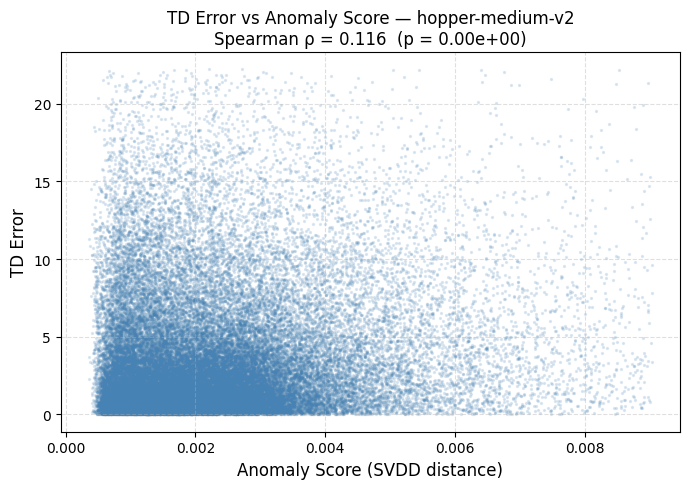

Saved to ../results/exp4_td_correlation_hopper-medium-v2.png


In [10]:
n = len(td_errors)
idx = np.random.choice(n, min(SUBSAMPLE, n), replace=False) if SUBSAMPLE > 0 else np.arange(n)

# Clip extreme outliers for scatter readability
p99_td   = np.percentile(td_errors,   99)
p99_anom = np.percentile(anom_scores, 99)
mask = (td_errors[idx] <= p99_td) & (anom_scores[idx] <= p99_anom)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(anom_scores[idx][mask], td_errors[idx][mask],
           alpha=0.15, s=2, color='steelblue', rasterized=True)
ax.set_xlabel('Anomaly Score (SVDD distance)', fontsize=12)
ax.set_ylabel('TD Error', fontsize=12)
ax.set_title(
    f'TD Error vs Anomaly Score — {ENV_ID}\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})',
    fontsize=12
)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

os.makedirs('../results', exist_ok=True)
out = f'../results/exp4_td_correlation_{ENV_ID}.png'
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved to {out}')

In [11]:
np.savez(f'../results/exp4_td_correlation_{ENV_ID}.npz',
         td_errors=td_errors, anom_scores=anom_scores)
print('Raw data saved.')

Raw data saved.
